# 2. VGG16 전이 학습 & ResNet vs VGG16 성능 비교

In [4]:
!pip install -q torch torchvision tqdm matplotlib

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from tqdm import tqdm

## 2-1. 데이터셋 준비

In [6]:
!pip install -q datasets
from datasets import load_dataset
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

_cifar10 = load_dataset('uoft-cs/cifar10')

class CIFAR10Dataset(torch.utils.data.Dataset):
    def __init__(self, split, transform=None):
        self.data = _cifar10[split]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]['img'], self.data[idx]['label']
        return self.transform(img) if self.transform else img, label

train_dataset = CIFAR10Dataset('train', transform=transform)
test_dataset  = CIFAR10Dataset('test',  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}, Train: {len(train_dataset)}, Test: {len(test_dataset)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Device: cuda, Train: 50000, Test: 10000


## 2-2. VGG16 전이 학습 (Feature Extraction)

In [7]:
vgg16 = models.vgg16(pretrained=True)

# Feature extraction: 사전 훈련된 가중치 동결
for param in vgg16.features.parameters():
    param.requires_grad = False

# 분류기 교체
vgg16.classifier[6] = nn.Linear(4096, 10)
vgg16 = vgg16.to(device)

print(vgg16.classifier)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:01<00:00, 301MB/s]


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=10, bias=True)
)


## 2-3. VGG16 학습

In [8]:
criterion = nn.CrossEntropyLoss()
vgg_optimizer = optim.Adam(filter(lambda p: p.requires_grad, vgg16.parameters()), lr=1e-4)

EPOCHS = 5
vgg_losses = []

for epoch in range(EPOCHS):
    vgg16.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f'[VGG16] Epoch {epoch+1}/{EPOCHS}', leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        vgg_optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        vgg_optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=f'{loss.item():.4f}')
    avg_loss = running_loss / len(train_loader)
    vgg_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}] VGG16 Loss: {avg_loss:.4f}')

Epoch [1/5] VGG16 Loss: 0.4859


Epoch [2/5] VGG16 Loss: 0.2275


Epoch [3/5] VGG16 Loss: 0.1150


Epoch [4/5] VGG16 Loss: 0.0758


Epoch [5/5] VGG16 Loss: 0.0629


## 2-4. ResNet18 학습 (비교용)

In [9]:
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

resnet_optimizer = optim.Adam(resnet.parameters(), lr=1e-4)
resnet_losses = []

for epoch in range(EPOCHS):
    resnet.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f'[ResNet18] Epoch {epoch+1}/{EPOCHS}', leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        resnet_optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        resnet_optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=f'{loss.item():.4f}')
    avg_loss = running_loss / len(train_loader)
    resnet_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}] ResNet18 Loss: {avg_loss:.4f}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


Epoch [1/5] ResNet18 Loss: 0.3341


Epoch [2/5] ResNet18 Loss: 0.1294


Epoch [3/5] ResNet18 Loss: 0.0723


Epoch [4/5] ResNet18 Loss: 0.0584


Epoch [5/5] ResNet18 Loss: 0.0452


## 2-5. 성능 비교

VGG16   Test Accuracy: 88.39%
ResNet18 Test Accuracy: 94.10%


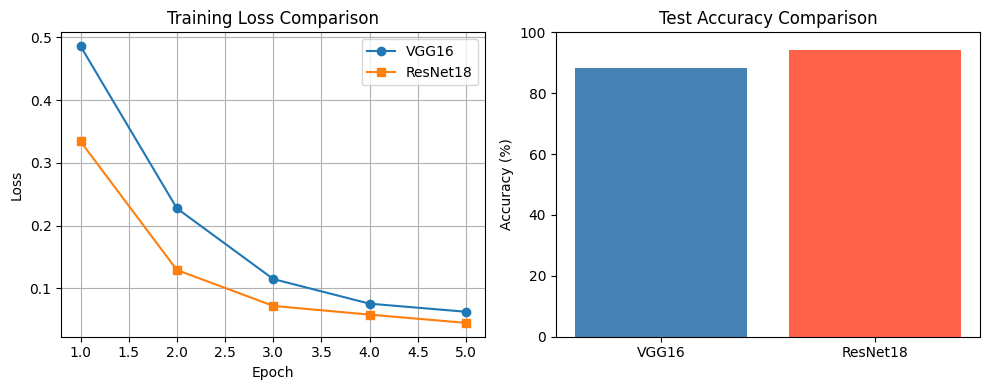

In [10]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total * 100

vgg_acc    = evaluate(vgg16,  test_loader)
resnet_acc = evaluate(resnet, test_loader)

print(f'VGG16   Test Accuracy: {vgg_acc:.2f}%')
print(f'ResNet18 Test Accuracy: {resnet_acc:.2f}%')

# Loss 곡선 비교
epochs = range(1, EPOCHS+1)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, vgg_losses, marker='o', label='VGG16')
plt.plot(epochs, resnet_losses, marker='s', label='ResNet18')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(['VGG16', 'ResNet18'], [vgg_acc, resnet_acc], color=['steelblue', 'tomato'])
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()